### Applied Partial Differential Equations | Richard Haberman | Solutions and Code by David A. Lee
### Chapter 3: Fourier Series
#### Section 3.2: Statement of the Convergence Theorem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim

Question 3.2.1

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color=FG, fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

In [3]:
L = 1.0
PERIODS = range(-2, 2)   # copies of (-L, L) covering [-3L, 3L]

L_ticks = [-3*L, -2*L, -L, 0, L, 2*L, 3*L]
L_labels = [r'$-3L$', r'$-2L$', r'$-L$', r'$0$', r'$L$', r'$2L$', r'$3L$']


def plot_fourier_series(pieces, label, fname, color, xticks=L_ticks, xticklabels=L_labels):
    """pieces: list of (a, b, g) with g smooth on (a, b); pieces partition (-L, L).

    Left: f(x) on [-L, L].  Right: what its Fourier series converges to on
    [-3L, 3L] -- the 2L-periodic extension of f, with the midpoint at every
    jump (open circles = one-sided limits, filled dot = average)."""
    fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 3]})

    # --- left: f itself on [-L, L]
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        ax[0].plot(x, g(x), color=color, linewidth=2.5)
    ax[0].plot([], [], color=color, linewidth=2.5, label=label)

    # --- right: periodic extension
    vals = []
    for k in PERIODS:
        for a, b, g in pieces:
            x = np.linspace(a, b, 400)
            y = g(x)
            vals.append(y)
            ax[1].plot(x + 2*k*L, y, color=color, linewidth=2.5)
    ax[1].plot([], [], color=color, linewidth=2.5, label='periodic extension of ' + label)

    # --- jumps: one-sided limits at every piece boundary, incl. x = +-L
    lefts  = {b: g(b) for a, b, g in pieces}   # limit from the left at x = b
    rights = {a: g(a) for a, b, g in pieces}   # limit from the right at x = a
    lefts[-L], rights[L] = lefts[L], rights[-L]  # periodicity wraps the ends
    for x0 in sorted(rights):
        lo, hi = lefts[x0], rights[x0]
        if not np.isclose(lo, hi):
            for k in PERIODS:
                xs = x0 + 2*k*L
                if -3*L <= xs <= 3*L:
                    ax[1].plot([xs, xs], [lo, hi], color=color, linestyle=':', linewidth=1)
                    ax[1].plot([xs, xs], [lo, hi], 'o', color=BG, markeredgecolor=color, markersize=6)
                    ax[1].plot(xs, (lo + hi)/2, 'o', color=color, markersize=6)

    # --- shared styling
    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    ylim = (v.min() - pad, v.max() + pad)
    inner = [i for i, t in enumerate(xticks) if abs(t) <= L]
    style_ax(ax[0], xlabel='$x$', ylabel='$f(x)$', xlim=(-L, L), ylim=ylim,
             xticks=[xticks[i] for i in inner], xticklabels=[xticklabels[i] for i in inner])
    style_ax(ax[1], xlabel='$x$', ylabel='', xlim=(-3*L, 3*L), ylim=ylim,
             xticks=xticks, xticklabels=xticklabels)
    ax[1].set_yticklabels([])
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
    ax[0].legend(frameon=True, fontsize=14, loc='lower left', bbox_to_anchor=(0, 1.02))
    ax[1].legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.02))
    for k in range(-3, 4, 2):
        ax[1].axvline(k*L, color=FG, linestyle='--', linewidth=1)

    fig.subplots_adjust(wspace=0.08)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

(a)

saved chap3sec3.2ex1a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1a.pdf


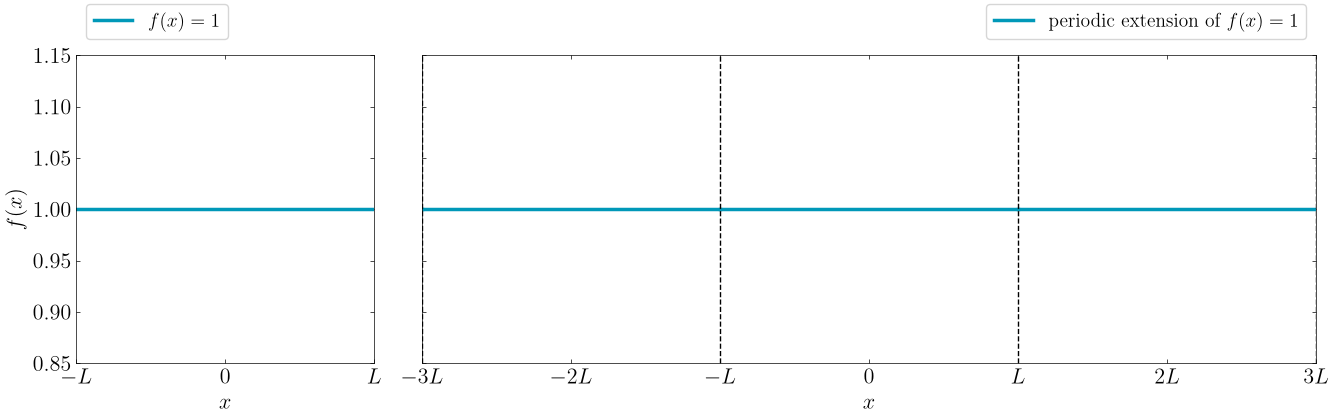

In [4]:
pieces = [(-L, L, lambda x: np.ones_like(x))]
plot_fourier_series(pieces, r"$f(x) = 1$", "chap3sec3.2ex1a.pdf", C.cyan)

(b)

saved chap3sec3.2ex1b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1b.pdf


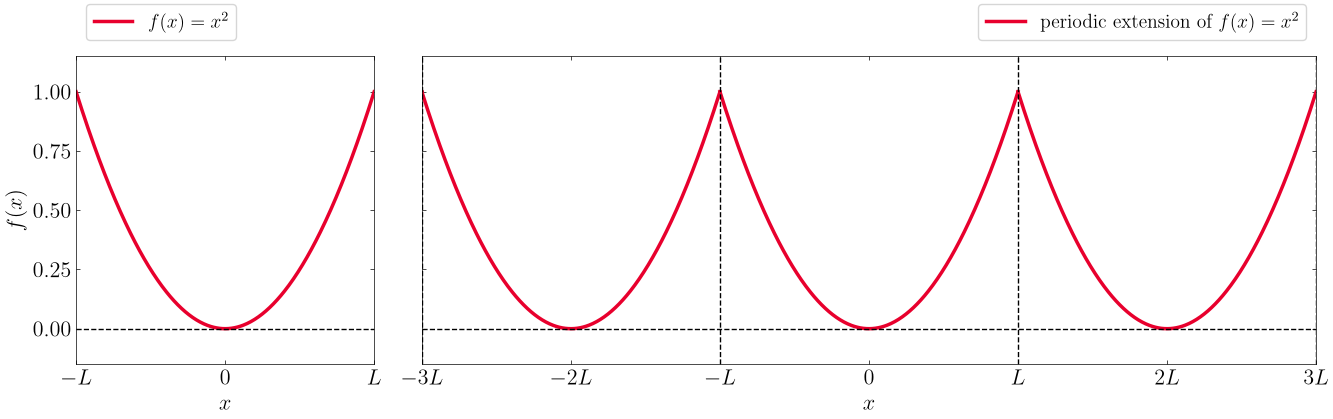

In [5]:
pieces = [(-L, L, lambda x: x**2)]
plot_fourier_series(pieces, r"$f(x) = x^{2}$", "chap3sec3.2ex1b.pdf", C.red)

(c)

saved chap3sec3.2ex1c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1c.pdf


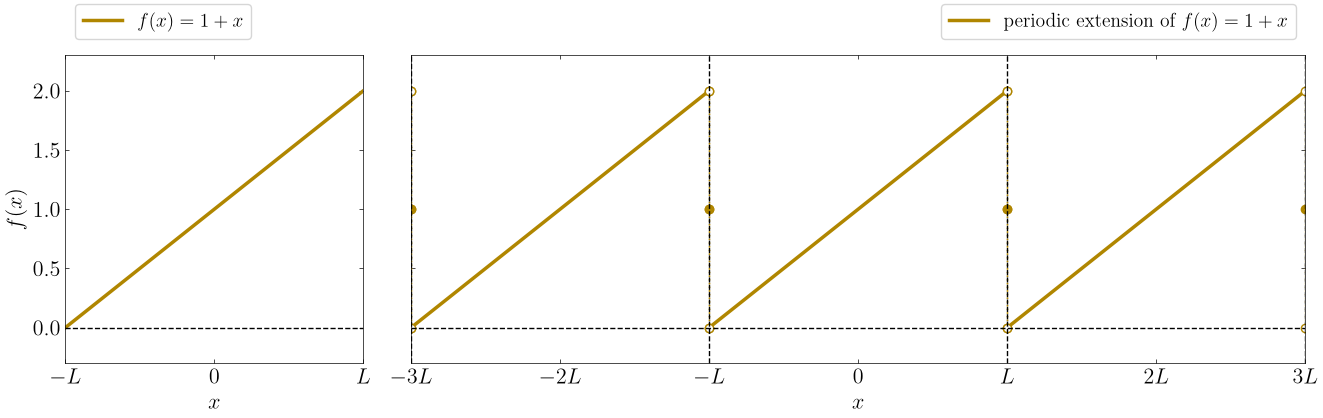

In [6]:
pieces = [(-L, L, lambda x: 1 + x)]
plot_fourier_series(pieces, r"$f(x) = 1 + x$", "chap3sec3.2ex1c.pdf", C.yellow)

(d)

saved chap3sec3.2ex1d.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1d.pdf


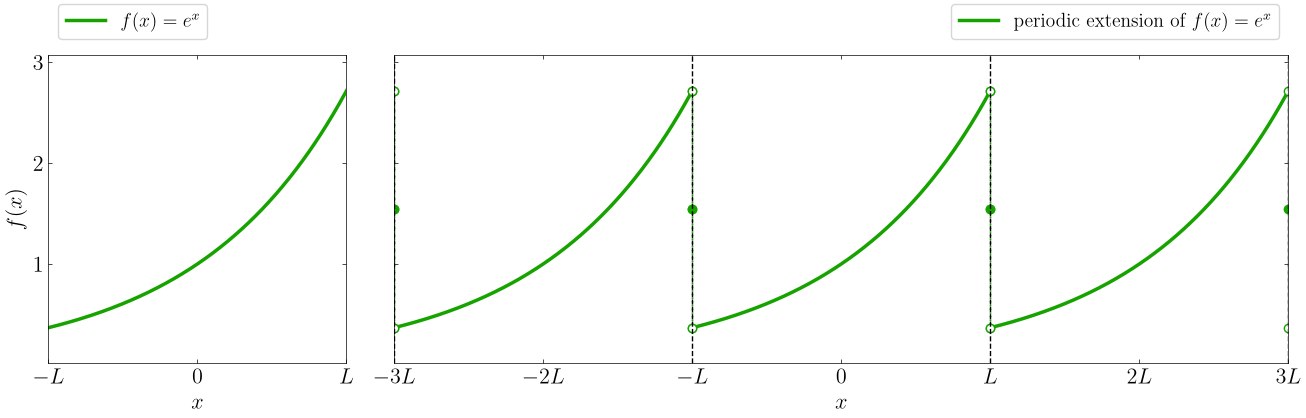

In [7]:
pieces = [(-L, L, lambda x: np.exp(x))]
plot_fourier_series(pieces, r"$f(x) = e^{x}$", "chap3sec3.2ex1d.pdf", C.green)

(e)

saved chap3sec3.2ex1e.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1e.pdf


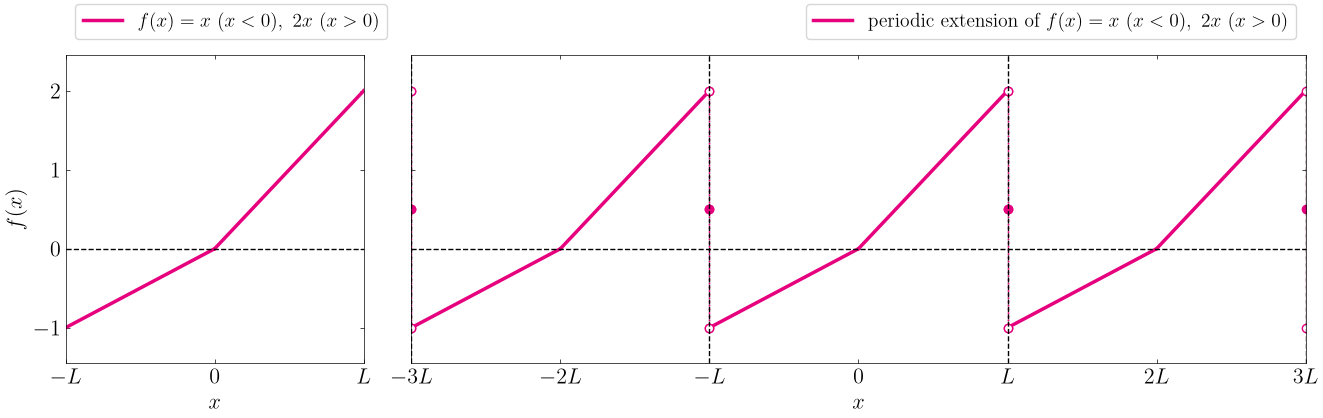

In [8]:
pieces = [(-L, 0, lambda x: x), (0, L, lambda x: 2*x)]
plot_fourier_series(pieces, r"$f(x) = x\ (x<0),\ 2x\ (x>0)$", "chap3sec3.2ex1e.pdf", C.magenta)

(f)

saved chap3sec3.2ex1f.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1f.pdf


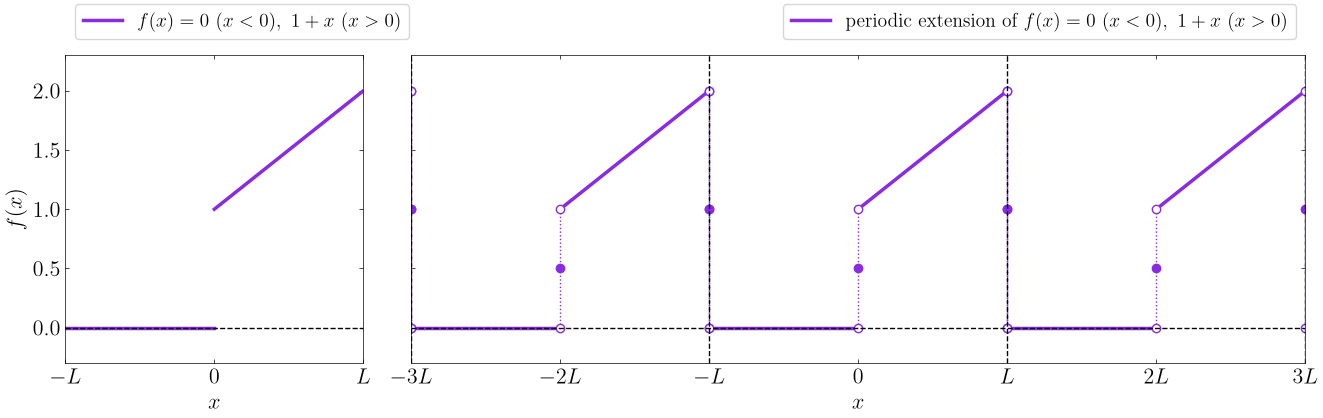

In [9]:
pieces = [(-L, 0, lambda x: np.zeros_like(x)), (0, L, lambda x: 1 + x)]
plot_fourier_series(pieces, r"$f(x) = 0\ (x<0),\ 1 + x\ (x>0)$", "chap3sec3.2ex1f.pdf", C.violet)

(g)

saved chap3sec3.2ex1g.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex1g.pdf


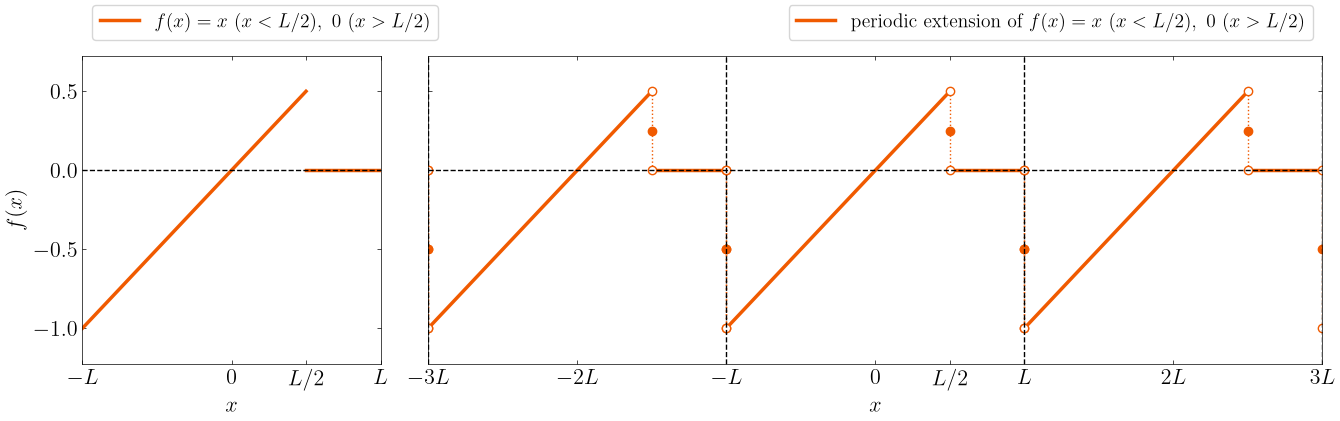

In [10]:
pieces = [(-L, L/2, lambda x: x), (L/2, L, lambda x: np.zeros_like(x))]
plot_fourier_series(pieces, r"$f(x) = x\ (x<L/2),\ 0\ (x>L/2)$", "chap3sec3.2ex1g.pdf", C.orange,
                    xticks=sorted(L_ticks + [L/2]), xticklabels=L_labels[:4] + [r'$L/2$'] + L_labels[4:])

Question 3.2.2

(a)

saved chap3sec3.2ex2a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2a.pdf


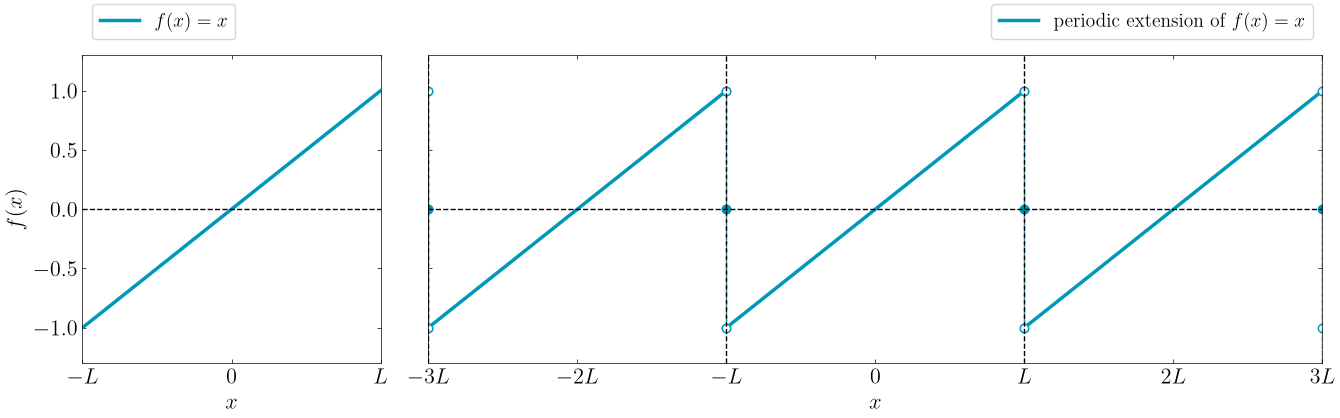

In [11]:
pieces = [(-L, L, lambda x: x)]
plot_fourier_series(pieces, r"$f(x) = x$", "chap3sec3.2ex2a.pdf", C.cyan)

(b)

saved chap3sec3.2ex2b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2b.pdf


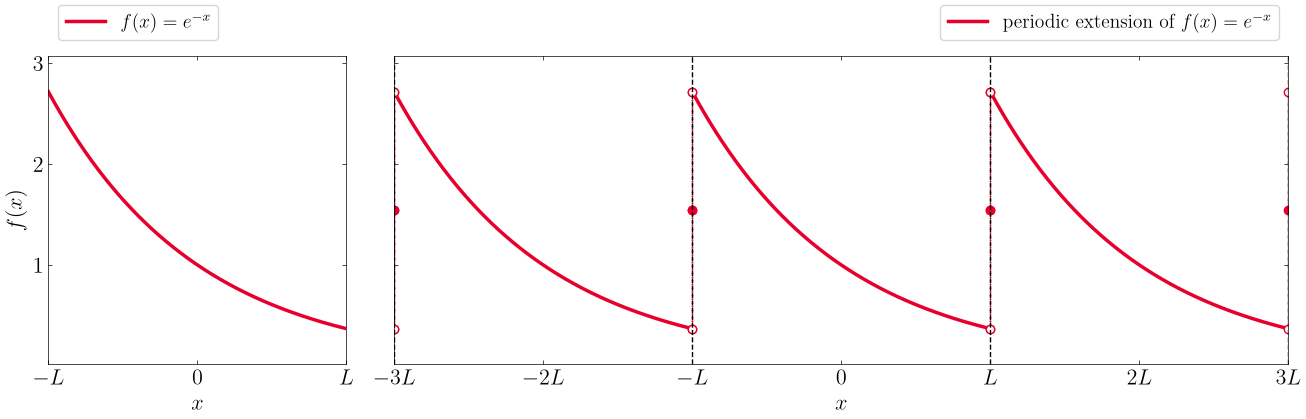

In [12]:
pieces = [(-L, L, lambda x: np.exp(-x))]
plot_fourier_series(pieces, r"$f(x) = e^{-x}$", "chap3sec3.2ex2b.pdf", C.red)

(c)

saved chap3sec3.2ex2c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2c.pdf


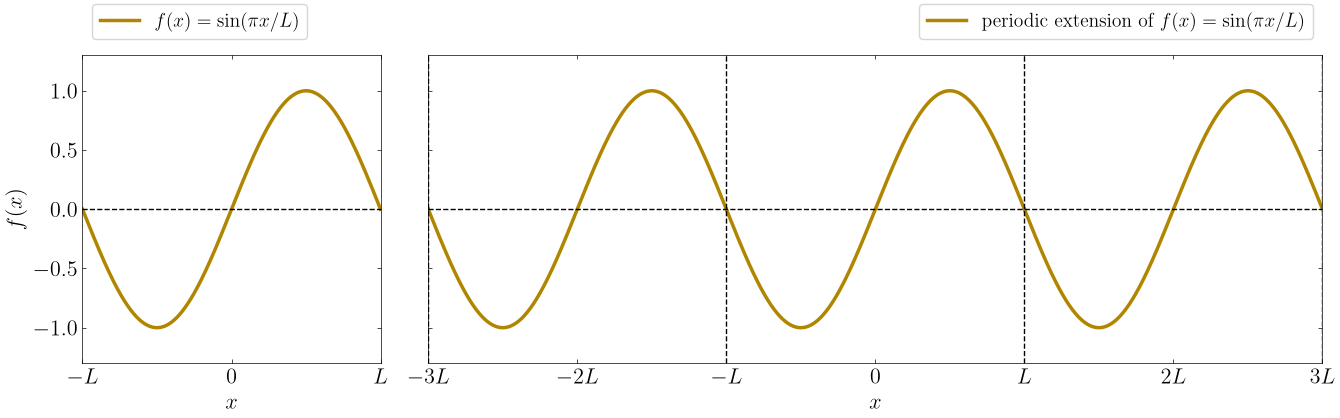

In [13]:
pieces = [(-L, L, lambda x: np.sin(np.pi*x/L))]
plot_fourier_series(pieces, r"$f(x) = \sin(\pi x / L)$", "chap3sec3.2ex2c.pdf", C.yellow)

(d)

saved chap3sec3.2ex2d.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2d.pdf


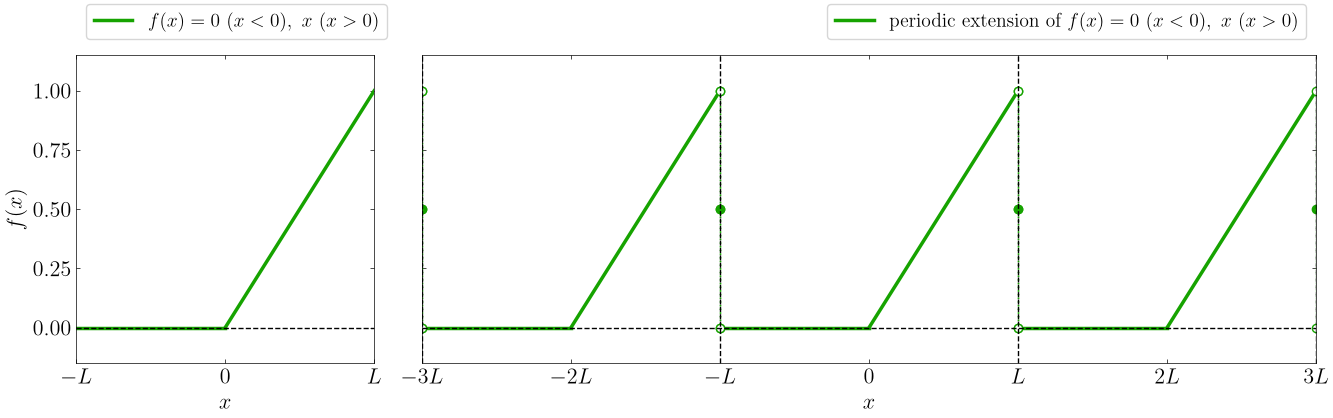

In [14]:
pieces = [(-L, 0, lambda x: np.zeros_like(x)), (0, L, lambda x: x)]
plot_fourier_series(pieces, r"$f(x) = 0\ (x<0),\ x\ (x>0)$", "chap3sec3.2ex2d.pdf", C.green)

(e)

saved chap3sec3.2ex2e.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2e.pdf


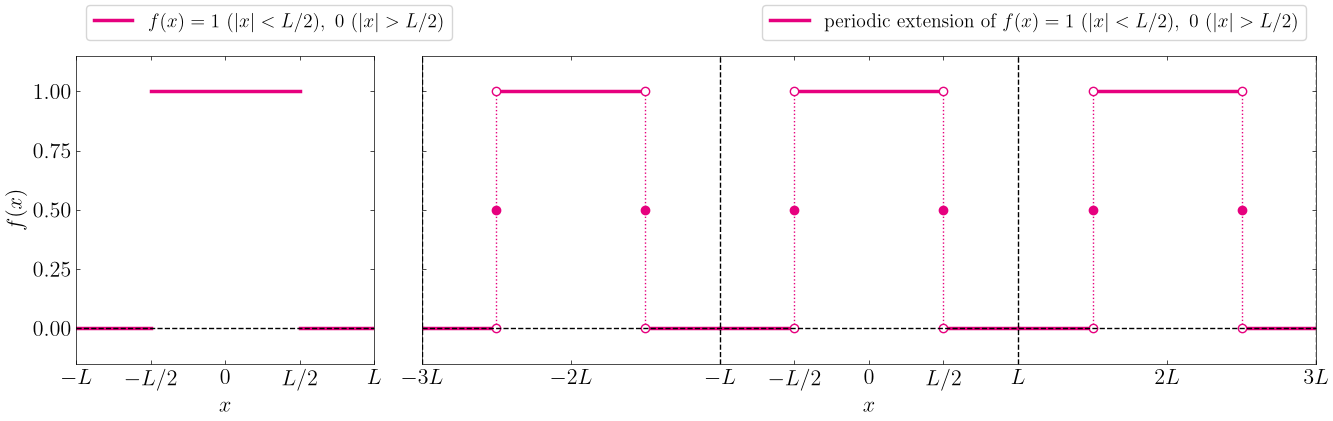

In [15]:
pieces = [(-L, -L/2, lambda x: np.zeros_like(x)), (-L/2, L/2, lambda x: np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
plot_fourier_series(pieces, r"$f(x) = 1\ (|x|<L/2),\ 0\ (|x|>L/2)$", "chap3sec3.2ex2e.pdf", C.magenta,
                    xticks=sorted(L_ticks + [-L/2, L/2]), xticklabels=L_labels[:3] + [r'$-L/2$', r'$0$', r'$L/2$'] + L_labels[4:])

(f)

saved chap3sec3.2ex2f.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2f.pdf


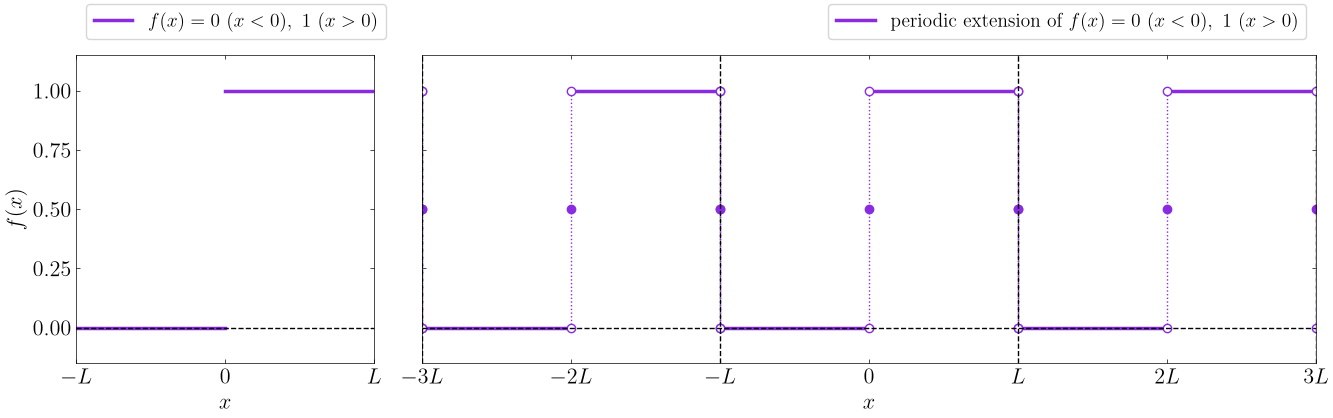

In [16]:
pieces = [(-L, 0, lambda x: np.zeros_like(x)), (0, L, lambda x: np.ones_like(x))]
plot_fourier_series(pieces, r"$f(x) = 0\ (x<0),\ 1\ (x>0)$", "chap3sec3.2ex2f.pdf", C.violet)

(g)

saved chap3sec3.2ex2g.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.2\chap3sec3.2ex2g.pdf


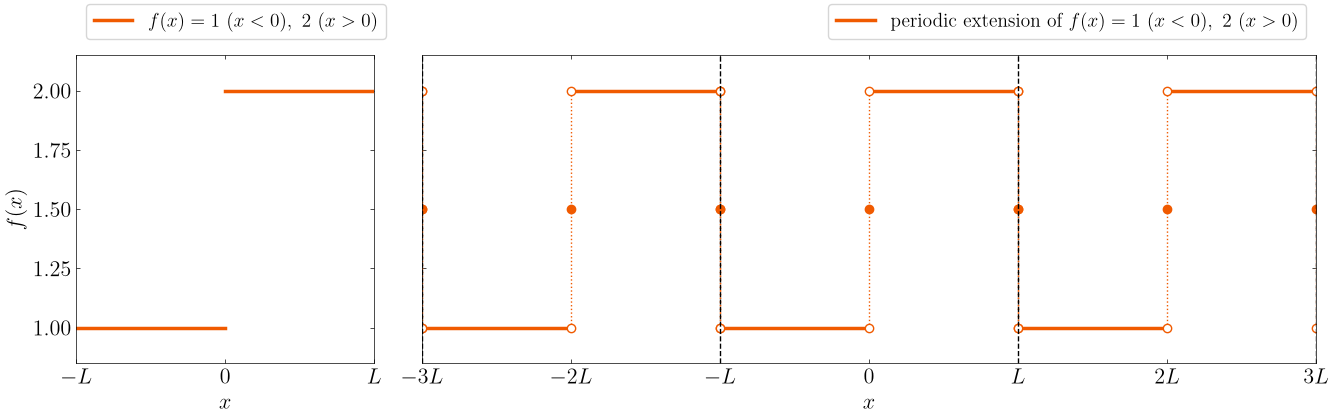

In [17]:
pieces = [(-L, 0, lambda x: np.ones_like(x)), (0, L, lambda x: 2*np.ones_like(x))]
plot_fourier_series(pieces, r"$f(x) = 1\ (x<0),\ 2\ (x>0)$", "chap3sec3.2ex2g.pdf", C.orange)